#   AI CA5
### Deniz Mostafazadegan_810102603

In [1]:
import torch
print(torch.cuda.is_available())

False


In [2]:
import pandas as pd
import numpy as np
import string
import matplotlib.pyplot as plt
import torch

In [3]:
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

In [4]:
from sentence_transformers import SentenceTransformer

c:\Users\lenovo\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download("punkt_tab")
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\lenovo\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\lenovo\AppData\Roaming\nltk_data...


True

In [6]:
import os
print(os.getcwd())


c:\Users\lenovo\Downloads


## ▶️ Load Dataset

In [8]:
df = pd.read_csv("C:\\Users\\lenovo\\Downloads\\AI_CA5\\musicLyrics.csv")

df = df.dropna(subset=['Lyric'])
df = df[df['Lyric'].str.strip() != '']
df.reset_index(drop=True, inplace=True)

#df.head()

## ▶️ Preprocessing Text

### ❓Why Do We Preprocess Text Data?
Text preprocessing transforms messy and inconsistent raw text into clean, meaningful, and structured input that is easier for models to analyze and learn from.
* Remove Noise -> ( I’m LOVING it!! \n → loving )
* Normalize the Text -> ( Run,running,ran → run )
* Improve Model Accuracy


### ✅ Lemmatization
Lemmatization is the process of reducing a word to its base or dictionary form using vocabulary and morphological analysis.

Unlike stemming, which simply chops off suffixes, lemmatization uses linguistic rules to ensure the resulting word is meaningful and grammatically correct.

* flies → fly
* better  → good


In [9]:
def clean_lyrics(text):
    if not isinstance(text, str):
        return ""

    text = text.lower()
    text = text.translate(str.maketrans("", "", string.punctuation))

    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stopwords.words("english")]

    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(t) for t in tokens]

    return " ".join(tokens)


In [10]:
from nltk.tokenize import word_tokenize
print(word_tokenize("This is a working test!"))


['This', 'is', 'a', 'working', 'test', '!']


In [11]:
df["cleaned_lyrics"] = df["Lyric"].apply(clean_lyrics)
df[["Lyric", "cleaned_lyrics"]].head()

,Lyric,cleaned_lyrics
0,Cryptic psalms Amidst the howling winds A scor...,cryptic psalm amidst howling wind scorching so...
1,Im sleeping tonight with all the wolves Were d...,im sleeping tonight wolf dreaming life thats b...
2,Wings of the darkest descent Fall from the rea...,wing darkest descent fall realm dark blackest ...
3,[Verse 1] Norrid Radd was my real name Had a j...,verse 1 norrid radd real name job hated every ...
4,Deep in the dungeons of doom and despair Sneak...,deep dungeon doom despair sneak place dark eke...


## ▶️Sentence Embedding

- means converting each sentence  into a numerical vector (a list of numbers that a machine learning algorithm can understand )


### ✔️ So we can:
- Compare lyrics based on meaning
- Cluster similar lyrics together
- Visualize and analyze them


In [14]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

corpus = df['cleaned_lyrics'].tolist()
embeddings = model.encode(corpus, show_progress_bar=True)

print("Embedding shape:", embeddings.shape)

Batches: 100%|██████████| 94/94 [05:43<00:00,  3.65s/it]

Embedding shape: (2999, 384)


## ▶️Clustering with KMeans
Group similar data points into K clusters.
## 📍Elbow Method
elbow point in the curve -> That’s the best K — adding more clusters after that doesn’t improve the result much


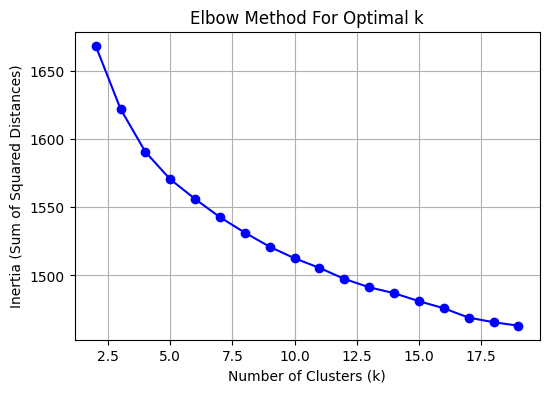

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

distortions = []
K = range(2, 20)

for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(embeddings)
    distortions.append(kmeans.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(K, distortions, 'bo-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia (Sum of Squared Distances)')
plt.title('Elbow Method For Optimal k')
plt.grid(True)
plt.show()


In [ ]:
from sklearn.cluster import KMeans

k = 10  
kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
labels_kmeans = kmeans.fit_predict(embeddings)

df['cluster_kmeans'] = labels_kmeans
print("K-Means clustering done.")


K-Means clustering done.


## ▶️Agglomerative Clustering
We try different linkage strategies to see which produces the best results.


In [17]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=k)
labels_hierarchical = agg.fit_predict(embeddings)

df['cluster_hierarchical'] = labels_hierarchical
print("Hierarchical clustering done.")


Hierarchical clustering done.


## ▶️Clustering with DBSCAN

In [18]:
from sklearn.cluster import DBSCAN

dbscan = DBSCAN(eps=0.6, min_samples=5, metric='euclidean')
labels_dbscan = dbscan.fit_predict(embeddings)

df['cluster_dbscan'] = labels_dbscan

unique_labels = set(labels_dbscan)
num_clusters = len(unique_labels) - (1 if -1 in unique_labels else 0)
num_noise = list(labels_dbscan).count(-1)


In [19]:
from sklearn.metrics import silhouette_score

# K-Means
score_kmeans = silhouette_score(embeddings, df['cluster_kmeans'])
print(f"K-Means Silhouette Score: {score_kmeans:.4f}")

# DBSCAN (exclude noise points labeled -1)
if num_clusters > 1:
    filtered_embeddings = embeddings[labels_dbscan != -1]
    filtered_labels = labels_dbscan[labels_dbscan != -1]
    sil_score = silhouette_score(filtered_embeddings, filtered_labels)
    print(f"Silhouette Score (DBSCAN, no noise): {sil_score:.4f}")
else:
    print("⚠️ Silhouette Score not meaningful: DBSCAN formed <2 clusters.")


# Hierarchical
score_hier = silhouette_score(embeddings, df['cluster_hierarchical'])
print(f"Hierarchical Silhouette Score: {score_hier:.4f}")


K-Means Silhouette Score: 0.0145
⚠️ Silhouette Score not meaningful: DBSCAN formed <2 clusters.
Hierarchical Silhouette Score: -0.0021


In [24]:
#df[['Lyric', 'cluster_kmeans', 'cluster_dbscan', 'cluster_hierarchical']].head()


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
reduced = pca.fit_transform(embeddings)

def plot_clusters(labels, title):
    plt.figure(figsize=(6, 4))
    plt.scatter(reduced[:, 0], reduced[:, 1], c=labels, cmap='tab10', s=10)
    plt.title(title)
    plt.xlabel('PCA 1')
    plt.ylabel('PCA 2')
    plt.grid(True)
    plt.show()



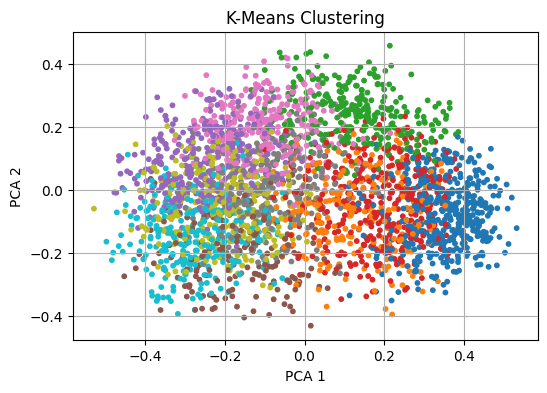

In [25]:
plot_clusters(df['cluster_kmeans'], 'K-Means Clustering')


In [23]:
for cluster in sorted(df['cluster_kmeans'].unique()):
    print(f"\nCluster {cluster} (K-Means):")
    samples = df[df['cluster_kmeans'] == cluster]['Lyric'].sample(2, random_state=42)
    for i, lyric in enumerate(samples):
        print(f"  Sample {i+1}:\n{lyric[:300]}...\n")


Cluster 0 (K-Means):
  Sample 1:
[Verse 1] Youre a dead man walking going hard on the brakes Its like youre DeadMan Walkn going hard on the breaks Im going to LA to roll over you, ese Then Ive got to get to New York today, roll over USA Set the car onto cruise control And roll on the roads that my crews control Nothing hits harder ...

  Sample 2:
[Hook Kid Kern] You know that I aint stressing anymore No telling what gon happen when that Hennessy get poured Been trynna figure out what all this jealousy is for They tell me Imma fail so I just tell em we aint worried We aint worried, we aint worried [Verse 1 Kid Kern] I been doing cool I guess ...


Cluster 1 (K-Means):
  Sample 1:
People expected you to fall, hit that same old wall Really they dont wanna help at all They talk behind your back today They shake their heads and they say Well, I always knew that the boy would come to no good anyway So I better pack up and go to Detroit or Buffalo Anybody wanna know where, you don...

  Sam

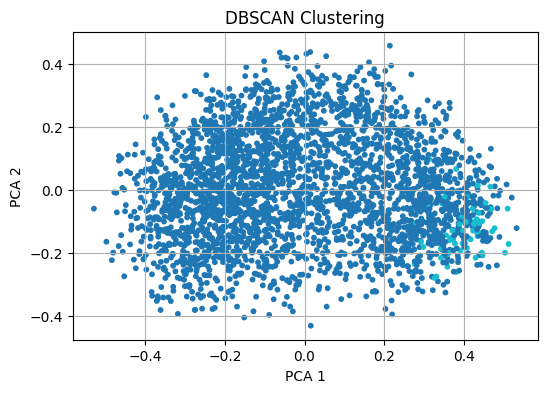

In [26]:
plot_clusters(df['cluster_dbscan'], 'DBSCAN Clustering')


In [27]:
for cluster in sorted(df['cluster_dbscan'].unique()):
    print(f"\nCluster {cluster} (K-Means):")
    samples = df[df['cluster_dbscan'] == cluster]['Lyric'].sample(2, random_state=42)
    for i, lyric in enumerate(samples):
        print(f"  Sample {i+1}:\n{lyric[:300]}...\n")



Cluster -1 (K-Means):
  Sample 1:
[Verse 1 Suburban Truth] Im a lyrical monster And these emcees I conquer concur Rhyme scripts and essays The auteur author They write outlines out of line Like coloring book contours Check the competition They produce like an Oompa Loompa Sell like a new computer But I rap around them like a Hula Ho...

  Sample 2:
Captured this mere man of mercy And held fast him to an iron grip Muscles tensed flexed humongous Tearing dove like wings to shreds Steel jawed set to devour Last feeble prayers remain unsaid Silenced by the machineries of war Forsaken monuments of dead loyalties Perished idyll messiahs complex His ...


Cluster 0 (K-Means):
  Sample 1:
[Verse 1] In my lil bros room bumping D Pryde If you dont know him, check him out, he need shine One of the best yet, like me Like Nas, like Jay, like P Thats 2Pac, uh, thats my favorite I used to hate Jay but now I play him I never realized how dope he was I was sleeping on him like opiates I still...

  Sa

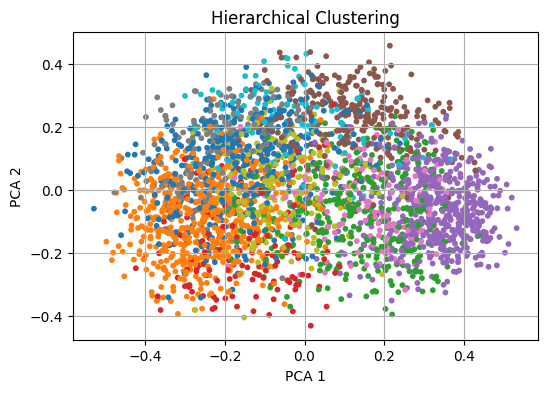

In [28]:
plot_clusters(df['cluster_hierarchical'], 'Hierarchical Clustering')


In [ ]:
for cluster in sorted(df['cluster_hierarchical'].unique()):
    print(f"\nCluster {cluster} (K-Means):")
    samples = df[df['cluster_hierarchical'] == cluster]['Lyric'].sample(2, random_state=42)
    for i, lyric in enumerate(samples):
        print(f"  Sample {i+1}:\n{lyric[:300]}...\n")



Cluster 0 (K-Means):
  Sample 1:
Dont you go and leave me here All alone in this sick dark world Ive got these demons to fight They make we weak and I cant do this all alone Ive fallen oh so far But if you leave me right now I wont, I wont, I wont make it out This isnt all about you This isnt, this isnt all about you Despite what y...

  Sample 2:
Dont ever mistake my patience, for being too kind Dont ever mistake my solitude, for having a good time Cause you pick me up, and you pour me out Cause you pick me up, and you pour me out Give me something to believe in Give me something to love Give me a little bit of anything And Ill give you a si...


Cluster 1 (K-Means):
  Sample 1:
Temptation frustration your love bleeds into hate You fed me this apple how bittersweet the taste I wonder if Ill breath again Then I inhale Suddenly I vaporize you Choking on your lies spitting out truth Open up your eyes to see that Im not standing here Suddenly I vaporize you Wear you like a scar...

  Sam

## ▶️PCA
### 🔷It transforms high-dimensional data (lots of features) into a smaller number of dimensions, while keeping the most important information.

In [29]:
from sklearn.decomposition import PCA


pca = PCA(n_components=2)
reduced_embeddings = pca.fit_transform(embeddings)

print("Reduced shape:", reduced_embeddings.shape)


Reduced shape: (2999, 2)


In [31]:
import matplotlib.pyplot as plt

def plot_clusters(points, labels, title="Cluster Plot"):
    plt.figure(figsize=(8,6))
    plt.scatter(points[:, 0], points[:, 1], c=labels, cmap='tab10', s=15)
    plt.title(title)
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.grid(True)
    plt.show()


In [41]:
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels_kmeans_pca = kmeans.fit_predict(reduced_embeddings)
df['kmeans_pca'] = labels_kmeans_pca

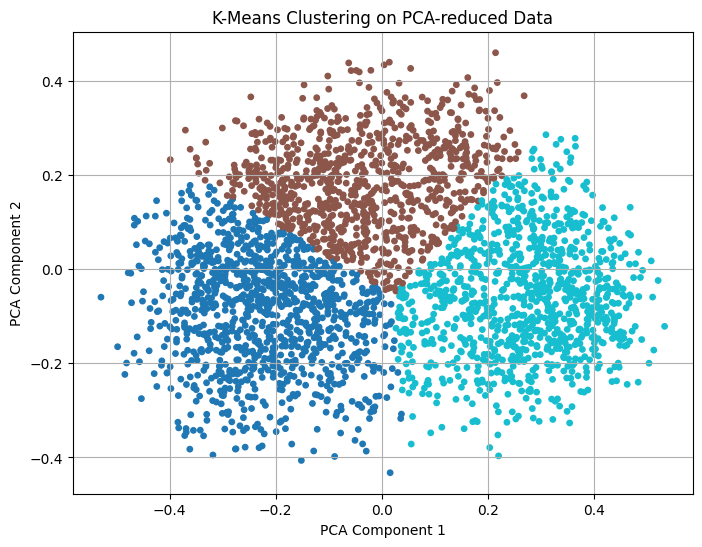

In [42]:
plot_clusters(reduced_embeddings, df['kmeans_pca'], "K-Means Clustering on PCA-reduced Data")


In [34]:
dbscan = DBSCAN(eps=0.05, min_samples=400)
labels_dbscan_pca = dbscan.fit_predict(reduced_embeddings)
df['dbscan_pca'] = labels_dbscan_pca

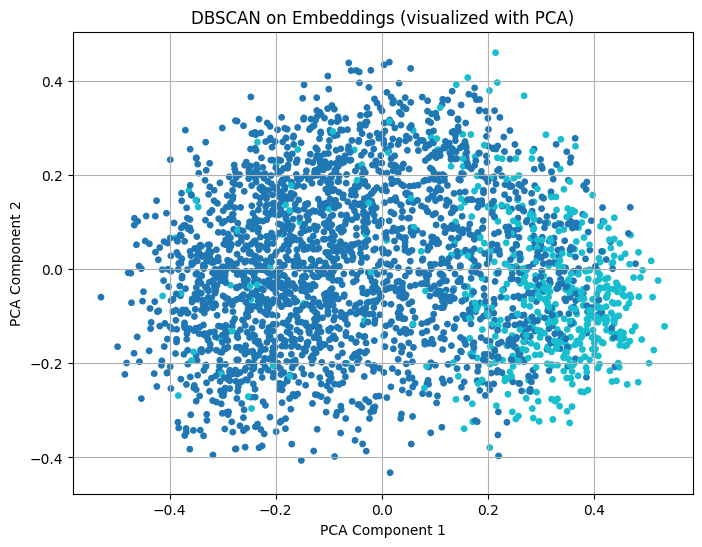

In [35]:
dbscan = DBSCAN(eps=0.7, min_samples=6)
labels_db = dbscan.fit_predict(embeddings)
df['cluster_dbscan'] = labels_db

plot_clusters(reduced_embeddings, df['cluster_dbscan'], "DBSCAN on Embeddings (visualized with PCA)")


In [39]:
from sklearn.cluster import AgglomerativeClustering

hier = AgglomerativeClustering(n_clusters=3)
labels_hier_pca = hier.fit_predict(reduced_embeddings)
df['hierarchical_pca'] = labels_hier_pca


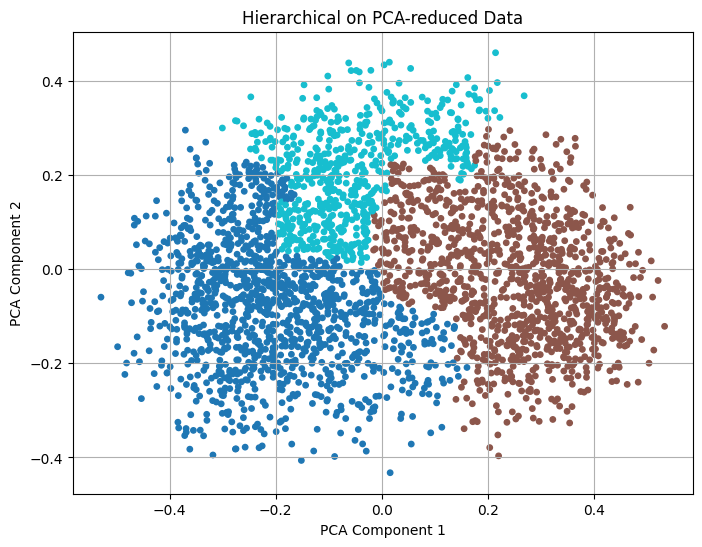

In [40]:
plot_clusters(reduced_embeddings, df['hierarchical_pca'], "Hierarchical on PCA-reduced Data")


# 🔁
- **KMeans** is fast and simple but assumes spherical clusters.
- **DBSCAN** detects arbitrary-shaped clusters and noise but is sensitive to *eps* and data scale.
- **Hierarchical Clustering** doesn't need a fixed number of clusters and can give better structure.

We'll compare them using **Silhouette Score**